[16:22:05] Device: cuda | dtype: torch.float64
[16:22:05] CUDA mem (start): 0 MB
[16:22:05] Symmetric norm: raw [-2.50,2.50] -> std [-1.00,1.00] (≈ -1,+1)
[16:22:05] Z_std head/tail: -1.000, 1.000
[16:22:17] [rep 001/100] Stage-1 (α=1.000) | best -ELBO=-1.698935 @epoch 729 | MSE=0.000151


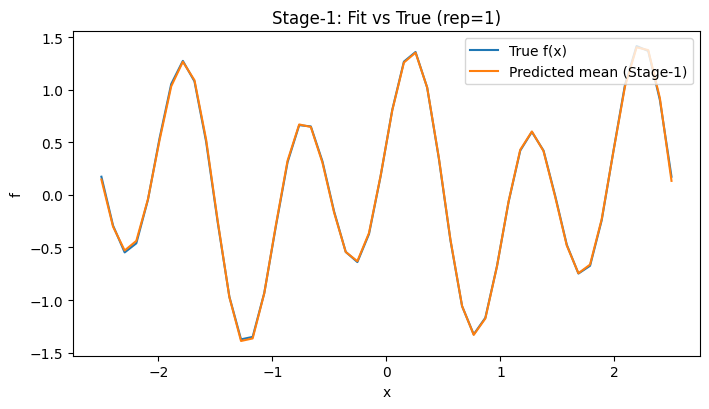

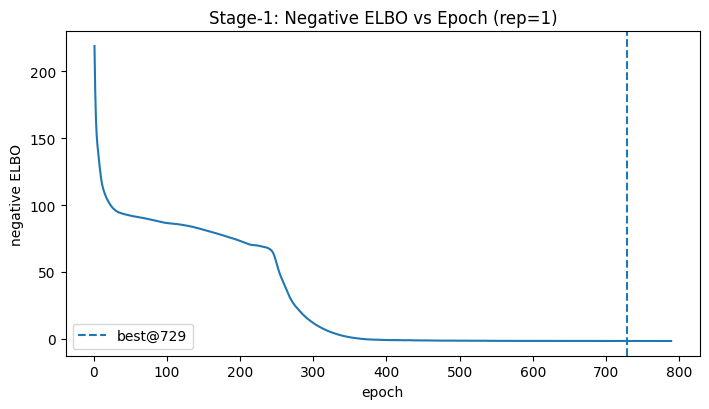

[16:22:37] [rep 001/100] α=1.000 (Stage-2) | best -ELBO=-1.708988 @epoch 1491 | MSE=0.000151
[16:22:37] [Checker] α=1.000: fraction(|bias|>band)=0.040; worst@x≈-2.194


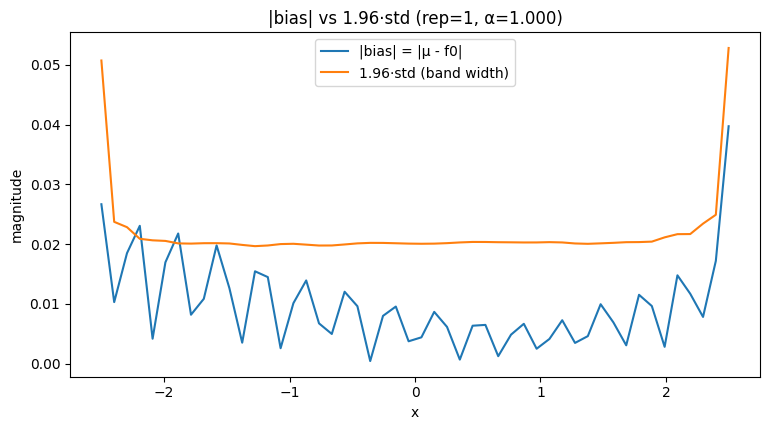

[16:23:00] [rep 001/100] α=0.800 (Stage-2) | best -ELBO=-1.649924 @epoch 1221 | MSE=0.000151
[16:23:24] [rep 001/100] α=0.600 (Stage-2) | best -ELBO=-1.553921 @epoch 1491 | MSE=0.000151
[16:23:49] [rep 001/100] α=0.500 (Stage-2) | best -ELBO=-1.478398 @epoch 1280 | MSE=0.000151
[16:23:49] [Checker] α=0.500: fraction(|bias|>band)=0.000; worst@x≈-1.888


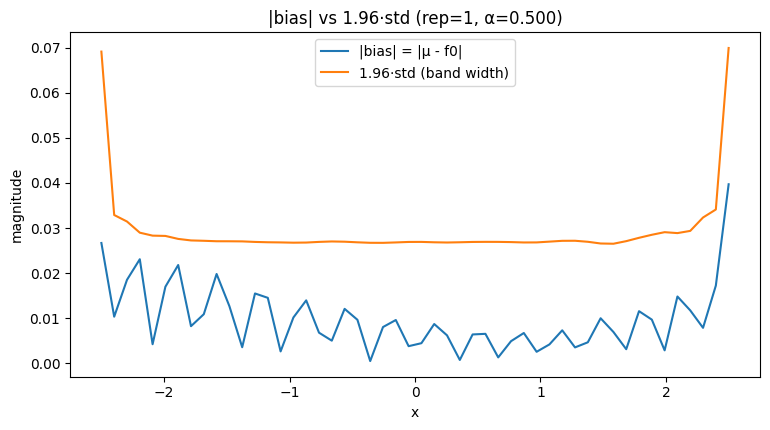

[16:24:14] [rep 001/100] α=0.300 (Stage-2) | best -ELBO=-1.182480 @epoch 1026 | MSE=0.000151
[16:24:39] [rep 001/100] α=0.100 (Stage-2) | best -ELBO=0.205533 @epoch 1437 | MSE=0.000151
[16:24:39] [Checker] α=0.100: fraction(|bias|>band)=0.000; worst@x≈-1.888


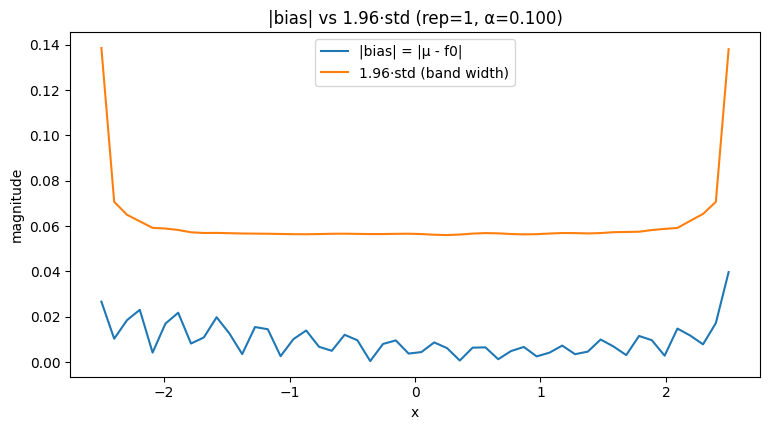

[16:25:04] [rep 001/100] α=0.001 (Stage-2) | best -ELBO=154.789987 @epoch 1278 | MSE=0.000151
[16:25:21] [rep 002/100] Stage-1 (α=1.000) | best -ELBO=-1.702879 @epoch 877 | MSE=0.000206
[16:25:46] [rep 002/100] α=1.000 (Stage-2) | best -ELBO=-1.698534 @epoch 1472 | MSE=0.000206
[16:26:11] [rep 002/100] α=0.800 (Stage-2) | best -ELBO=-1.639619 @epoch 1020 | MSE=0.000206
[16:26:37] [rep 002/100] α=0.600 (Stage-2) | best -ELBO=-1.543338 @epoch 1265 | MSE=0.000206
[16:27:02] [rep 002/100] α=0.500 (Stage-2) | best -ELBO=-1.468184 @epoch 1203 | MSE=0.000206
[16:27:27] [rep 002/100] α=0.300 (Stage-2) | best -ELBO=-1.173171 @epoch 1332 | MSE=0.000206
[16:27:52] [rep 002/100] α=0.100 (Stage-2) | best -ELBO=0.211315 @epoch 1066 | MSE=0.000206
[16:28:17] [rep 002/100] α=0.001 (Stage-2) | best -ELBO=154.296415 @epoch 1258 | MSE=0.000206
[16:28:37] [rep 003/100] Stage-1 (α=1.000) | best -ELBO=-1.725305 @epoch 1028 | MSE=0.000058
[16:29:01] [rep 003/100] α=1.000 (Stage-2) | best -ELBO=-1.730654 @epo

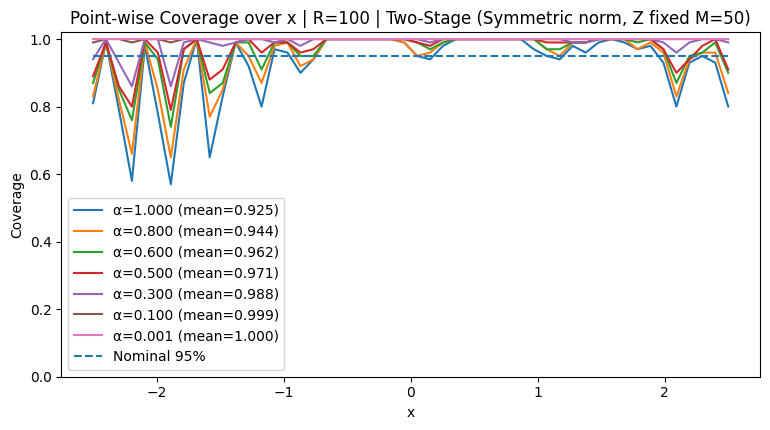

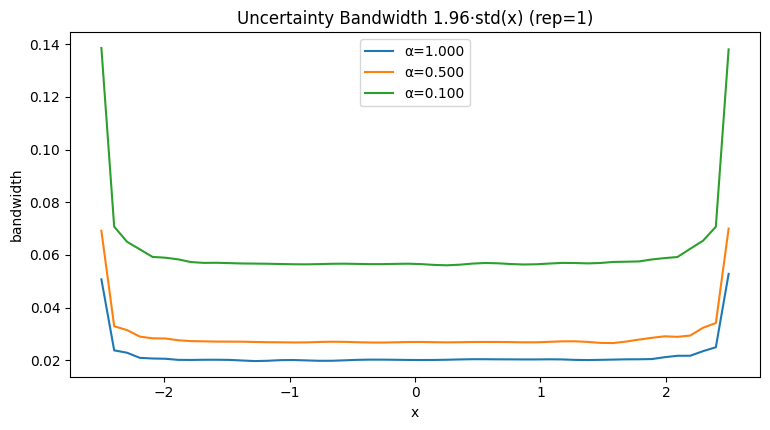

[21:16:08] Saved health summary to health_summary.csv
[21:16:08] 
=== Health summary (head) ===
[21:16:08]  alpha  mean_coverage  mse_mean   mse_sd  neg_elbo_mean  neg_elbo_sd  lengthscale_mean  lengthscale_sd  outputscale_mean  outputscale_sd  avg_bandwidth_mean  avg_bandwidth_sd  frac_tiny_std_mean
   1.0         0.9252  0.000209 0.000209      -1.702447     0.030130          0.194047        0.000675          1.948069        0.048799            0.022882          0.001181                 0.0
   0.8         0.9440  0.000209 0.000209      -1.643800     0.031494          0.194047        0.000675          1.948069        0.048799            0.024971          0.001098                 0.0
   0.6         0.9618  0.000209 0.000209      -1.547689     0.033874          0.194047        0.000675          1.948069        0.048799            0.027935          0.000822                 0.0
   0.5         0.9708  0.000209 0.000209      -1.471996     0.035800          0.194047        0.000675          1

In [2]:
# svgp_ciq_regression_alpha_suite_twostage_symnorm_plus.py
# Two-stage SVGP (latent-f only) with SYMMETRIC LINEAR NORMALIZATION:
#   x_std = (x_raw - mid) / half, mapping [train_low, train_high] -> [-1, 1]
# Train/test/Z share the SAME global transform. Z: M=50, fixed & not learnable.
# Stage-1 (alpha=1): train kernel + variational mean (noise fixed; Z fixed).
# Stage-2 (alphas): reload Stage-1, train ONLY variational covariance with beta=1/alpha.
# NEW:
#   (1) Heatmaps for alphas in {1.0, 0.5, 0.1}
#   (2) Extra diagnostics: standardized residual QQ plot (rep=1)
#   (3) Uncertainty bandwidth plot (rep=1, three alphas)
#   (4) Health summary table per alpha (CSV)

import math, time
from contextlib import ExitStack
from dataclasses import dataclass

import torch, gpytorch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# ---------------- logging ----------------
def now(): return time.strftime("%H:%M:%S")
def log(msg): print(f"[{now()}] {msg}", flush=True)
def gpu_mem_mb(): return (torch.cuda.memory_allocated()/1e6) if torch.cuda.is_available() else 0.0

# ---------------- helpers ----------------
def has_setting(name: str) -> bool: return hasattr(gpytorch.settings, name)

def ciq_context():
    stack = ExitStack()
    for name, val in [
        ("num_contour_quadrature", 15),
        ("ciq_samples", 16),
        ("ciq_max_iter", 30),
        ("ciq_forward_precision", 0.01),
        ("eval_cg_tolerance", 1e-4),
        ("max_root_decomposition_size", 64),
    ]:
        if has_setting(name):
            stack.enter_context(getattr(gpytorch.settings, name)(val))
    stack.enter_context(gpytorch.settings.fast_pred_var(True))
    return stack

def clone_state_dict(sd):
    out = {}
    for k, v in sd.items():
        out[k] = v.detach().clone() if torch.is_tensor(v) else v
    return out

# true latent f (noiseless)
def f0(x: torch.Tensor) -> torch.Tensor:
    return torch.sin(2 * math.pi * x) + 0.5 * torch.cos(3 * x)

# 1D stratified (LHS-like) points — used ONCE globally
def make_stratified_points_1d(n, low, high, generator, device, dtype):
    i = torch.arange(n, device=device, dtype=dtype)
    u = (i + torch.rand(n, generator=generator, device=device, dtype=dtype)) / n
    x = low + (high - low) * u
    perm = torch.randperm(n, generator=generator, device=device)
    return x[perm].unsqueeze(-1)

# ---------------- config ----------------
@dataclass
class CFG:
    # data
    n_train: int = 500
    n_test: int = 50
    train_low: float = -2.5
    train_high: float = 2.5
    test_low: float = -2.5
    test_high: float = 2.5

    # model/train
    use_fp64: bool = True
    use_ciq: bool = False
    inducing_points: int = 50
    stage1_epochs: int = 5000
    stage2_epochs: int = 1500
    batch_size: int = 500
    lr_adam_stage1: float = 2e-2
    lr_adam_stage2: float = 2e-2
    jitter: float = 1e-2
    seed: int = 13

    # early stopping
    early_stop_patience: int = 60
    early_stop_min_delta: float = 1e-4

    # experiment
    alphas: tuple = (1.0, 0.8, 0.6, 0.5, 0.3, 0.1, 0.001)
    replications: int = 100

    # logging/plots
    log_epoch: bool = False
    log_every: int = 10
    show_plots: bool = True
    save_plots: bool = True

    # extras
    heatmap_alphas: tuple = (1.0, 0.5, 0.1)   # which alphas to heatmap/diagnose

# ---------------- model ----------------
class SVGPModel(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points_std: torch.Tensor):
        M = inducing_points_std.size(0)
        q_dist = gpytorch.variational.CholeskyVariationalDistribution(M)
        q_strat = gpytorch.variational.VariationalStrategy(
            self, inducing_points_std, q_dist, learn_inducing_locations=False
        )
        super().__init__(q_strat)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x_std):
        mean_x = self.mean_module(x_std)
        covar_x = self.covar_module(x_std)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# ---------------- two-stage param helpers ----------------
def freeze_all_params(model, likelihood):
    for p in model.parameters(): p.requires_grad_(False)
    for p in likelihood.parameters(): p.requires_grad_(False)

def pick_covariance_params_svgp(model):
    """Select ONLY variational covariance parameters (exclude any '*mean*')."""
    trainables, names = [], []
    vdist_mod = None
    vs = getattr(model, "variational_strategy", None)
    if vs is not None:
        if hasattr(vs, "_variational_distribution"):
            vdist_mod = getattr(vs, "_variational_distribution")
        else:
            cand = getattr(vs, "variational_distribution", None)
            if isinstance(cand, torch.nn.Module):
                vdist_mod = cand
    if isinstance(vdist_mod, torch.nn.Module):
        for n, p in vdist_mod.named_parameters(recurse=True):
            low = n.lower()
            if "mean" in low:
                p.requires_grad_(False)
            elif any(k in low for k in ["chol", "std", "var", "covar", "factor"]):
                p.requires_grad_(True); trainables.append(p); names.append(f"vdist.{n}")
            else:
                p.requires_grad_(False)
    if not trainables:
        allow = (
            "chol_variational_covar","variational_distribution.chol_covar",
            "variational_distribution._cholesky_factor","_variational_distribution.chol_covar",
            "raw_covar","chol_factor","covar_factor","variational_stddev","raw_var",
            "qchol","q_scale_tril"
        )
        for n, p in model.named_parameters():
            low = n.lower()
            if "variational_strategy" in low and any(k in low for k in allow) and "mean" not in low:
                p.requires_grad_(True); trainables.append(p); names.append(n)
    return trainables, names

# ---------------- Stage-1 ----------------
def stage1_train(model, likelihood, x_train_std, y_train, lr, epochs, jitter, batch_size,
                 early_stop_patience, early_stop_min_delta, log_epoch=False, log_every=10):
    N = x_train_std.size(0)
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=N, beta=1.0)

    likelihood.noise_covar.raw_noise.requires_grad_(False)
    opt = torch.optim.Adam([
        {"params": model.variational_parameters()},
        {"params": model.hyperparameters()},
        {"params": likelihood.parameters()},
    ], lr=lr)

    loader = DataLoader(TensorDataset(x_train_std, y_train),
                        batch_size=batch_size, shuffle=True, drop_last=False)

    model.train(); likelihood.train()
    neg_elbo_hist, best_loss, best_epoch = [], float("inf"), 0
    best_model_sd = clone_state_dict(model.state_dict())
    best_lik_sd   = clone_state_dict(likelihood.state_dict())
    patience = 0

    with gpytorch.settings.cholesky_jitter(jitter):
        for ep in range(1, epochs + 1):
            total, n_batches = 0.0, 0
            for xb, yb in loader:
                opt.zero_grad(set_to_none=True)
                out = model(xb)
                loss = -mll(out, yb)
                if loss.numel() > 1: loss = loss.mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                opt.step()
                total += float(loss.item()); n_batches += 1
            avg_loss = total / max(1, n_batches)
            neg_elbo_hist.append(avg_loss)

            if best_loss - avg_loss > early_stop_min_delta:
                best_loss, best_epoch = avg_loss, ep
                best_model_sd = clone_state_dict(model.state_dict())
                best_lik_sd   = clone_state_dict(likelihood.state_dict())
                patience = 0
            else:
                patience += 1

            if log_epoch and (ep % log_every == 0 or ep == 1 or ep == epochs):
                log(f"[S1] epoch {ep:04d}/{epochs} | -ELBO={avg_loss:.6f} (best {best_loss:.6f}@{best_epoch})")

            if patience >= early_stop_patience: break

    model.load_state_dict(best_model_sd)
    likelihood.load_state_dict(best_lik_sd)
    model.eval(); likelihood.eval()
    return neg_elbo_hist, best_epoch, best_loss

# ---------------- Stage-2 ----------------
def stage2_train_cov_only(model, likelihood, x_train_std, y_train, beta, lr, epochs, jitter, batch_size):
    N = x_train_std.size(0)
    freeze_all_params(model, likelihood)
    cov_params, cov_names = pick_covariance_params_svgp(model)
    assert cov_params, "No covariance params found to train in Stage-2."
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=N, beta=beta)
    opt = torch.optim.Adam(cov_params, lr=lr)

    loader = DataLoader(TensorDataset(x_train_std, y_train),
                        batch_size=batch_size, shuffle=True, drop_last=False)

    model.train(); likelihood.train()
    neg_elbo_hist, best_loss, best_epoch = [], float("inf"), 0
    best_model_sd = clone_state_dict(model.state_dict())
    best_lik_sd   = clone_state_dict(likelihood.state_dict())

    with gpytorch.settings.cholesky_jitter(jitter):
        for ep in range(1, epochs + 1):
            total, n_batches = 0.0, 0
            for xb, yb in loader:
                opt.zero_grad(set_to_none=True)
                out = model(xb)
                loss = -mll(out, yb)
                if loss.numel() > 1: loss = loss.mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(cov_params, 5.0)
                opt.step()
                total += float(loss.item()); n_batches += 1
            avg_loss = total / max(1, n_batches)
            neg_elbo_hist.append(avg_loss)
            if avg_loss < best_loss:
                best_loss, best_epoch = avg_loss, ep
                best_model_sd = clone_state_dict(model.state_dict())
                best_lik_sd   = clone_state_dict(likelihood.state_dict())

    model.load_state_dict(best_model_sd)
    likelihood.load_state_dict(best_lik_sd)
    model.eval(); likelihood.eval()
    return neg_elbo_hist, best_epoch, best_loss, cov_names

# ---------------- plotting helpers ----------------
def plot_heatmap(ind_mat, x_axis, alpha, out_prefix="heatmap", vmin=0.0, vmax=1.0):
    """ind_mat: [R,J] 0/1 coverage matrix for a given alpha"""
    plt.figure(figsize=(9, 4.8))
    plt.imshow(ind_mat, aspect="auto", interpolation="nearest",
               vmin=vmin, vmax=vmax, extent=[x_axis.min(), x_axis.max(), ind_mat.shape[0], 0])
    plt.colorbar(label="coverage (0/1)")
    plt.xlabel("x")
    plt.ylabel("replication")
    plt.title(f"Coverage Heatmap (α={alpha:.3f})  — rows: reps, cols: x-grid")
    plt.tight_layout()
    plt.savefig(f"{out_prefix}_alpha{alpha:.3f}.png", dpi=150)
    plt.close()

def qq_plot(z, alpha, out_prefix="qqplot"):
    """Standard normal QQ plot without external deps."""
    z = np.asarray(z)
    z = z[np.isfinite(z)]
    z_sorted = np.sort(z)
    n = z_sorted.size
    if n == 0:
        return
    # plotting positions (avoid 0/1 at ends)
    p = (np.arange(1, n+1) - 0.5) / n
    q_theory = np.sqrt(2) * torch.erfinv(torch.tensor(2*p - 1)).numpy()
    plt.figure(figsize=(5.6, 5.2))
    plt.plot(q_theory, z_sorted, ".", markersize=3)
    # y=x reference
    lim = float(np.nanmax(np.abs(np.concatenate([q_theory, z_sorted]))))
    lim = max(lim, 3.0)
    plt.plot([-lim, lim], [-lim, lim], "k--", linewidth=1)
    plt.xlabel("Theoretical quantiles  N(0,1)")
    plt.ylabel("Sample quantiles of z")
    plt.title(f"QQ plot of standardized residuals (rep=1, α={alpha:.3f})")
    plt.tight_layout()
    plt.savefig(f"{out_prefix}_alpha{alpha:.3f}.png", dpi=150)
    plt.close()

# ---------------- main ----------------
def main():
    cfg = CFG()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.set_default_dtype(torch.float64 if cfg.use_fp64 else torch.float32)

    # seeds
    torch.manual_seed(cfg.seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(cfg.seed)

    log(f"Device: {device} | dtype: {torch.get_default_dtype()}")
    if torch.cuda.is_available(): log(f"CUDA mem (start): {gpu_mem_mb():.0f} MB")

    # ---- GLOBAL fixed train/test (RAW) ----
    gen = torch.Generator(device=device).manual_seed(cfg.seed)
    x_train_raw = make_stratified_points_1d(
        n=cfg.n_train, low=cfg.train_low, high=cfg.train_high,
        generator=gen, device=device, dtype=torch.get_default_dtype()
    )
    x_test_raw = torch.linspace(cfg.test_low, cfg.test_high, cfg.n_test,
                                device=device, dtype=torch.get_default_dtype()).unsqueeze(1)
    y_train = f0(x_train_raw).squeeze(-1)
    y_test_true = f0(x_test_raw).squeeze(-1)

    # ---- SYMMETRIC normalization (one-time) ----
    mid = torch.tensor([(cfg.train_low + cfg.train_high)/2.0],
                       device=device, dtype=torch.get_default_dtype())
    half = torch.tensor([(cfg.train_high - cfg.train_low)/2.0],
                        device=device, dtype=torch.get_default_dtype()).clamp_min(1e-12)
    def to_std(x_raw): return (x_raw - mid) / half

    x_train_std = to_std(x_train_raw)
    x_test_std  = to_std(x_test_raw)
    Z_raw = torch.linspace(cfg.train_low, cfg.train_high, cfg.inducing_points,
                           device=device, dtype=torch.get_default_dtype()).unsqueeze(1)
    Z_std = to_std(Z_raw)

    # quick sanity
    left_std = float(to_std(torch.tensor([[cfg.train_low]], device=device)))
    right_std = float(to_std(torch.tensor([[cfg.train_high]], device=device)))
    log(f"Symmetric norm: raw [{cfg.train_low:.2f},{cfg.train_high:.2f}] -> std [{left_std:.2f},{right_std:.2f}] (≈ -1,+1)")
    log(f"Z_std head/tail: {float(Z_std[0]):.3f}, {float(Z_std[-1]):.3f}")

    # ---- storage (coverage & health) ----
    alphas = list(cfg.alphas)
    A, R, J = len(alphas), cfg.replications, cfg.n_test
    indicators = np.zeros((A, R, J), dtype=np.float64)

    mse_mat = np.zeros((A, R))
    elbo_mat = np.zeros((A, R))
    ls_mat = np.zeros((A, R))
    os_mat = np.zeros((A, R))
    avg_bandwidth_mat = np.zeros((A, R))
    frac_tiny_std_mat = np.zeros((A, R))  # fraction of std < 1e-9 (health)

    rep_to_plot = 0
    smallest_alpha = min(alphas)

    # for bandwidth overlay at rep=1
    band_curves_rep1 = {}

    for r in range(R):
        # build model/likelihood fresh with fixed Z_std
        model = SVGPModel(Z_std.clone().contiguous()).to(device=device)
        likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device=device)
        with torch.no_grad():
            model.covar_module.base_kernel.lengthscale.fill_(1.0)
            model.covar_module.outputscale.fill_(1.0)
            likelihood.noise = torch.as_tensor(3e-3, dtype=torch.get_default_dtype(), device=device)
        likelihood.noise_covar.raw_noise.requires_grad_(False)

        # ---- Stage-1 (alpha=1) ----
        with (ciq_context() if cfg.use_ciq else ExitStack()):
            neg_elbo_hist_s1, best_epoch_s1, best_loss_s1 = stage1_train(
                model, likelihood, x_train_std, y_train,
                lr=cfg.lr_adam_stage1, epochs=cfg.stage1_epochs, jitter=cfg.jitter,
                batch_size=cfg.batch_size,
                early_stop_patience=cfg.early_stop_patience,
                early_stop_min_delta=cfg.early_stop_min_delta,
                log_epoch=cfg.log_epoch, log_every=cfg.log_every
            )

        with torch.no_grad():
            pred_f = model(x_test_std)
            mu_pred = pred_f.mean
            mse_s1 = torch.mean((mu_pred - y_test_true)**2).item()

        log(f"[rep {r+1:03d}/{R}] Stage-1 (α=1.000) | best -ELBO={best_loss_s1:.6f} @epoch {best_epoch_s1} | MSE={mse_s1:.6f}")

        if r == rep_to_plot:
            # Fit vs True
            plt.figure(figsize=(7.2, 4.2))
            plt.plot(x_test_raw.squeeze(-1).cpu(), y_test_true.cpu().numpy(), label="True f(x)")
            plt.plot(x_test_raw.squeeze(-1).cpu(), mu_pred.cpu().numpy(), label="Predicted mean (Stage-1)")
            plt.title(f"Stage-1: Fit vs True (rep={r+1})")
            plt.xlabel("x"); plt.ylabel("f"); plt.legend(); plt.tight_layout()
            if cfg.save_plots: plt.savefig(f"stage1_fit_vs_true_rep{r+1}_symnorm.png", dpi=150)
            if cfg.show_plots: plt.show()
            else: plt.close()

            # -ELBO curve
            plt.figure(figsize=(7.2, 4.2))
            plt.plot(range(1, len(neg_elbo_hist_s1)+1), neg_elbo_hist_s1)
            plt.axvline(best_epoch_s1, linestyle="--", label=f"best@{best_epoch_s1}")
            plt.title(f"Stage-1: Negative ELBO vs Epoch (rep={r+1})")
            plt.xlabel("epoch"); plt.ylabel("negative ELBO"); plt.legend(); plt.tight_layout()
            if cfg.save_plots: plt.savefig(f"stage1_neg_elbo_rep{r+1}_symnorm.png", dpi=150)
            if cfg.show_plots: plt.show()
            else: plt.close()

        # checkpoint after Stage-1
        s1_model_sd = clone_state_dict(model.state_dict())
        s1_lik_sd   = clone_state_dict(likelihood.state_dict())

        # ---- Stage-2 across alphas ----
        for a_idx, alpha in enumerate(alphas):
            beta = 1.0 / alpha
            model.load_state_dict(s1_model_sd)
            likelihood.load_state_dict(s1_lik_sd)
            model.eval(); likelihood.eval()

            with (ciq_context() if cfg.use_ciq else ExitStack()):
                neg_elbo_hist_s2, best_epoch_s2, best_loss_s2, cov_names = stage2_train_cov_only(
                    model, likelihood, x_train_std, y_train,
                    beta=beta, lr=cfg.lr_adam_stage2, epochs=cfg.stage2_epochs,
                    jitter=cfg.jitter, batch_size=cfg.batch_size
                )

            with torch.no_grad():
                pred_f = model(x_test_std)
                mu = pred_f.mean
                var = pred_f.variance
                std = var.sqrt().clamp_min(1e-12)
                lower, upper = mu - 1.96*std, mu + 1.96*std
                cover = ((y_test_true >= lower) & (y_test_true <= upper)).to(torch.float64)
                indicators[a_idx, r, :] = cover.cpu().numpy()
                mse = torch.mean((mu - y_test_true)**2).item()

                # health stats
                ls = float(model.covar_module.base_kernel.lengthscale.mean())
                os = float(model.covar_module.outputscale)
                elbo_mat[a_idx, r] = float(best_loss_s2)
                mse_mat[a_idx, r] = float(mse)
                ls_mat[a_idx, r] = ls
                os_mat[a_idx, r] = os
                avg_bandwidth_mat[a_idx, r] = float((1.96*std).mean().item())
                frac_tiny_std_mat[a_idx, r] = float((std < 1e-9).to(torch.float32).mean().item())

                if r == rep_to_plot and (alpha in cfg.heatmap_alphas):
                    band_curves_rep1[alpha] = (x_test_raw.squeeze(-1).cpu().numpy(),
                                               (1.96*std).cpu().numpy())

            log(f"[rep {r+1:03d}/{R}] α={alpha:.3f} (Stage-2) | best -ELBO={best_loss_s2:.6f} @epoch {best_epoch_s2} | MSE={mse:.6f}")

            # ---- Extra diagnostics at rep=1 for chosen alphas ----
            if r == rep_to_plot and (alpha in cfg.heatmap_alphas):
                # |bias| vs band （已有）
                abs_bias = (mu - y_test_true).abs()
                band = 1.96*std
                frac_viol = float((abs_bias > band).to(torch.float32).mean())
                worst_idx = int(torch.argmax(abs_bias - band).item())
                x_worst = float(x_test_raw[worst_idx])
                log(f"[Checker] α={alpha:.3f}: fraction(|bias|>band)={frac_viol:.3f}; worst@x≈{x_worst:.3f}")

                xs = x_test_raw.squeeze(-1).cpu().numpy()
                plt.figure(figsize=(7.8, 4.4))
                plt.plot(xs, abs_bias.cpu().numpy(), label="|bias| = |μ - f0|")
                plt.plot(xs, band.cpu().numpy(), label="1.96·std (band width)")
                plt.title(f"|bias| vs 1.96·std (rep=1, α={alpha:.3f})")
                plt.xlabel("x"); plt.ylabel("magnitude"); plt.legend(); plt.tight_layout()
                if cfg.save_plots: plt.savefig(f"checker_bias_vs_band_rep1_alpha{alpha:.3f}_symnorm.png", dpi=150)
                if cfg.show_plots: plt.show()
                else: plt.close()

                # 标准化残差 QQ 图
                z = ((y_test_true - mu) / std).cpu().numpy()
                qq_plot(z, alpha, out_prefix="qqplot_rep1_symnorm")

    # ---- coverage curves（整体） ----
    x_axis = x_test_raw.squeeze(-1).cpu().numpy()
    coverage_curves = indicators.mean(axis=1)   # [A, J]
    overall_cov = coverage_curves.mean(axis=1)  # [A]

    plt.figure(figsize=(7.8, 4.4))
    for a_idx, alpha in enumerate(alphas):
        plt.plot(x_axis, coverage_curves[a_idx], label=f"α={alpha:.3f} (mean={overall_cov[a_idx]:.3f})")
    plt.hlines(0.95, x_axis.min(), x_axis.max(), linestyles="--", label="Nominal 95%")
    plt.ylim(0.0, 1.02)
    plt.title(f"Point-wise Coverage over x | R={cfg.replications} | Two-Stage (Symmetric norm, Z fixed M={cfg.inducing_points})")
    plt.xlabel("x"); plt.ylabel("Coverage"); plt.legend(); plt.tight_layout()
    if cfg.save_plots: plt.savefig(f"coverage_curves_R{cfg.replications}_twostage_symnorm.png", dpi=150)
    if cfg.show_plots: plt.show()
    else: plt.close()

    # ---- (1) Heatmaps for selected alphas ----
    for a_sel in cfg.heatmap_alphas:
        if a_sel in alphas:
            idx = alphas.index(a_sel)
            plot_heatmap(indicators[idx], x_axis, a_sel,
                         out_prefix=f"coverage_heatmap_R{cfg.replications}_symnorm")

    # ---- (3) Uncertainty bandwidth overlay (rep=1) for selected alphas ----
    if band_curves_rep1:
        plt.figure(figsize=(7.8, 4.4))
        for a_sel in cfg.heatmap_alphas:
            if a_sel in band_curves_rep1:
                xs, band = band_curves_rep1[a_sel]
                plt.plot(xs, band, label=f"α={a_sel:.3f}")
        plt.title("Uncertainty Bandwidth 1.96·std(x) (rep=1)")
        plt.xlabel("x"); plt.ylabel("bandwidth")
        plt.legend(); plt.tight_layout()
        if cfg.save_plots: plt.savefig("bandwidth_overlay_rep1_symnorm.png", dpi=150)
        if cfg.show_plots: plt.show()
        else: plt.close()

    # ---- (4) Health summary table per alpha ----
    rows = []
    for a_idx, alpha in enumerate(alphas):
        row = {
            "alpha": alpha,
            "mean_coverage": float(overall_cov[a_idx]),
            "mse_mean": float(np.mean(mse_mat[a_idx])),
            "mse_sd": float(np.std(mse_mat[a_idx])),
            "neg_elbo_mean": float(np.mean(elbo_mat[a_idx])),
            "neg_elbo_sd": float(np.std(elbo_mat[a_idx])),
            "lengthscale_mean": float(np.mean(ls_mat[a_idx])),
            "lengthscale_sd": float(np.std(ls_mat[a_idx])),
            "outputscale_mean": float(np.mean(os_mat[a_idx])),
            "outputscale_sd": float(np.std(os_mat[a_idx])),
            "avg_bandwidth_mean": float(np.mean(avg_bandwidth_mat[a_idx])),
            "avg_bandwidth_sd": float(np.std(avg_bandwidth_mat[a_idx])),
            "frac_tiny_std_mean": float(np.mean(frac_tiny_std_mat[a_idx])),
        }
        rows.append(row)
    df = pd.DataFrame(rows)
    df = df[[
        "alpha","mean_coverage",
        "mse_mean","mse_sd",
        "neg_elbo_mean","neg_elbo_sd",
        "lengthscale_mean","lengthscale_sd",
        "outputscale_mean","outputscale_sd",
        "avg_bandwidth_mean","avg_bandwidth_sd",
        "frac_tiny_std_mean"
    ]]
    df.to_csv("health_summary.csv", index=False)
    log("Saved health summary to health_summary.csv")
    log("\n=== Health summary (head) ===")
    log(df.head().to_string(index=False))

    # ---- Save indicators for reproducibility ----
    np.save("indicator_matrix_twostage_symnorm.npy", indicators)
    log(f"Saved indicator matrix with shape {indicators.shape} to indicator_matrix_twostage_symnorm.npy")

if __name__ == "__main__":
    main()


[05:01:32] Device: cuda | dtype: torch.float64
[05:01:32] CUDA mem (start): 18 MB
[05:01:32] Symmetric norm: raw [-2.50,2.50] -> std [-1.00,1.00] (≈ -1,+1)
[05:01:32] Z_std head/tail: -1.000, 1.000
[05:01:44] [rep 001/100] Stage-1 (α=1.000) | best -ELBO=-1.698935 @epoch 729 | MSE=0.000151


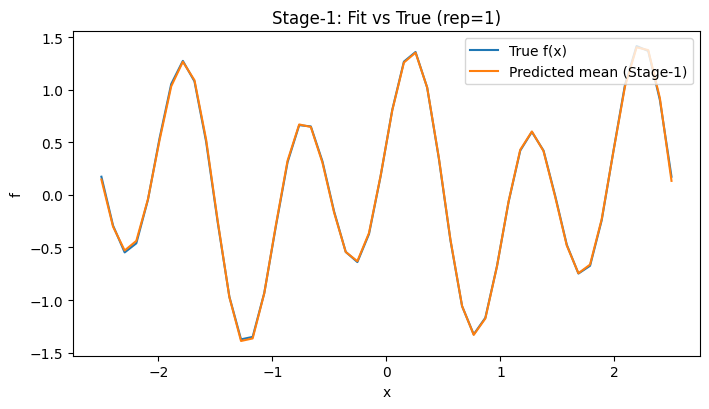

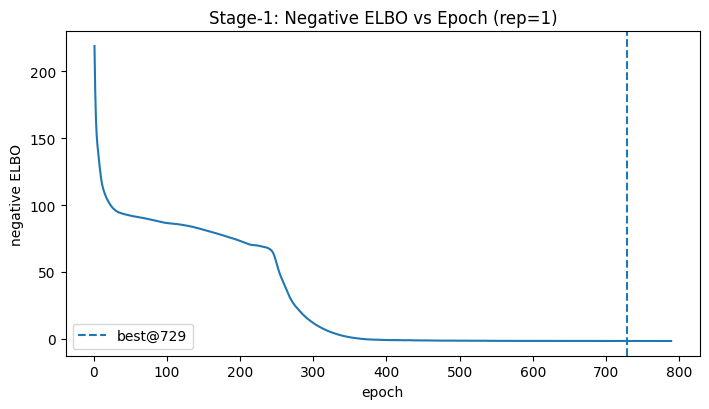

[05:02:01] [rep 001/100] α=1.000 (Stage-2) | best -ELBO=-1.708988 @epoch 1491 | MSE=0.000151
[05:02:13] [rep 002/100] Stage-1 (α=1.000) | best -ELBO=-1.696310 @epoch 718 | MSE=0.000163
[05:02:32] [rep 002/100] α=1.000 (Stage-2) | best -ELBO=-1.706410 @epoch 1241 | MSE=0.000163
[05:02:44] [rep 003/100] Stage-1 (α=1.000) | best -ELBO=-1.707743 @epoch 823 | MSE=0.000097
[05:03:00] [rep 003/100] α=1.000 (Stage-2) | best -ELBO=-1.719264 @epoch 1352 | MSE=0.000097
[05:03:13] [rep 004/100] Stage-1 (α=1.000) | best -ELBO=-1.703143 @epoch 754 | MSE=0.000148
[05:03:37] [rep 004/100] α=1.000 (Stage-2) | best -ELBO=-1.708410 @epoch 1329 | MSE=0.000148
[05:03:48] [rep 005/100] Stage-1 (α=1.000) | best -ELBO=-1.658921 @epoch 650 | MSE=0.000370
[05:04:04] [rep 005/100] α=1.000 (Stage-2) | best -ELBO=-1.674556 @epoch 1285 | MSE=0.000370
[05:04:16] [rep 006/100] Stage-1 (α=1.000) | best -ELBO=-1.714698 @epoch 956 | MSE=0.000079
[05:04:32] [rep 006/100] α=1.000 (Stage-2) | best -ELBO=-1.722308 @epoch 14

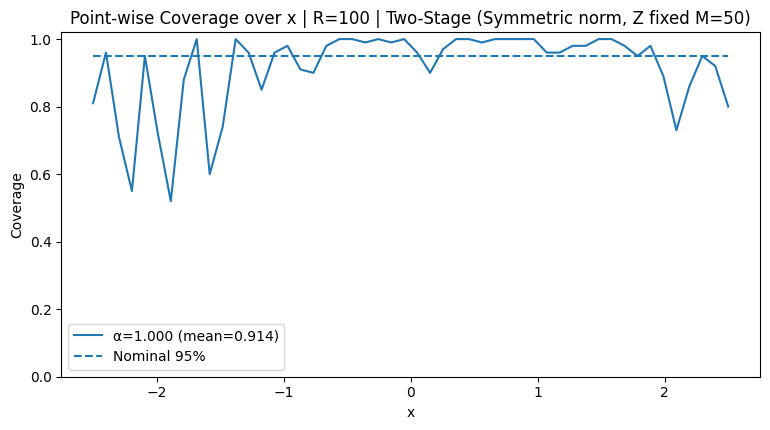

[06:03:20] Saved health summary to health_summary.csv
[06:03:20] 
=== Health summary (head) ===
[06:03:20]  alpha  mean_coverage  mse_mean   mse_sd  neg_elbo_mean  neg_elbo_sd  lengthscale_mean  lengthscale_sd  outputscale_mean  outputscale_sd  avg_bandwidth_mean  avg_bandwidth_sd  frac_tiny_std_mean
   1.0         0.9144  0.000228 0.000207      -1.699341     0.029622          0.194118        0.000731          1.941442        0.049728            0.022829          0.001191                 0.0
[06:03:20] Saved indicator matrix with shape (1, 100, 50) to indicator_matrix_twostage_symnorm.npy


In [2]:
# svgp_ciq_regression_alpha_suite_twostage_symnorm_plus.py
# Two-stage SVGP (latent-f only) with SYMMETRIC LINEAR NORMALIZATION:
#   x_std = (x_raw - mid) / half, mapping [train_low, train_high] -> [-1, 1]
# Train/test/Z share the SAME global transform. Z: M=50, fixed & not learnable.
# Stage-1 (alpha=1): train kernel + variational mean (noise fixed; Z fixed).
# Stage-2 (alphas): reload Stage-1, train ONLY variational covariance with beta=1/alpha.
# NEW:
#   (1) Heatmaps for alphas in {1.0, 0.5, 0.1}
#   (2) Extra diagnostics: standardized residual QQ plot (rep=1)
#   (3) Uncertainty bandwidth plot (rep=1, three alphas)
#   (4) Health summary table per alpha (CSV)

import math, time
from contextlib import ExitStack
from dataclasses import dataclass

import torch, gpytorch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# ---------------- logging ----------------
def now(): return time.strftime("%H:%M:%S")
def log(msg): print(f"[{now()}] {msg}", flush=True)
def gpu_mem_mb(): return (torch.cuda.memory_allocated()/1e6) if torch.cuda.is_available() else 0.0

# ---------------- helpers ----------------
def has_setting(name: str) -> bool: return hasattr(gpytorch.settings, name)

def ciq_context():
    stack = ExitStack()
    for name, val in [
        ("num_contour_quadrature", 15),
        ("ciq_samples", 16),
        ("ciq_max_iter", 30),
        ("ciq_forward_precision", 0.01),
        ("eval_cg_tolerance", 1e-4),
        ("max_root_decomposition_size", 64),
    ]:
        if has_setting(name):
            stack.enter_context(getattr(gpytorch.settings, name)(val))
    stack.enter_context(gpytorch.settings.fast_pred_var(True))
    return stack

def clone_state_dict(sd):
    out = {}
    for k, v in sd.items():
        out[k] = v.detach().clone() if torch.is_tensor(v) else v
    return out

# true latent f (noiseless)
def f0(x: torch.Tensor) -> torch.Tensor:
    return torch.sin(2 * math.pi * x) + 0.5 * torch.cos(3 * x)

# 1D stratified (LHS-like) points — used ONCE globally
def make_stratified_points_1d(n, low, high, generator, device, dtype):
    i = torch.arange(n, device=device, dtype=dtype)
    u = (i + torch.rand(n, generator=generator, device=device, dtype=dtype)) / n
    x = low + (high - low) * u
    perm = torch.randperm(n, generator=generator, device=device)
    return x[perm].unsqueeze(-1)

# ---------------- config ----------------
@dataclass
class CFG:
    # data
    n_train: int = 500
    n_test: int = 50
    train_low: float = -2.5
    train_high: float = 2.5
    test_low: float = -2.5
    test_high: float = 2.5

    # model/train
    use_fp64: bool = True
    use_ciq: bool = False
    inducing_points: int = 50
    stage1_epochs: int = 5000
    stage2_epochs: int = 1500
    batch_size: int = 500
    lr_adam_stage1: float = 2e-2
    lr_adam_stage2: float = 2e-2
    jitter: float = 1e-2
    seed: int = 13

    # early stopping
    early_stop_patience: int = 60
    early_stop_min_delta: float = 1e-4

    # experiment
    alphas: tuple = (1.0,)
    replications: int = 100

    # logging/plots
    log_epoch: bool = False
    log_every: int = 10
    show_plots: bool = True
    save_plots: bool = True

    # extras
    heatmap_alphas: tuple = ()   # which alphas to heatmap/diagnose

# ---------------- model ----------------
class SVGPModel(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points_std: torch.Tensor):
        M = inducing_points_std.size(0)
        q_dist = gpytorch.variational.CholeskyVariationalDistribution(M)
        q_strat = gpytorch.variational.VariationalStrategy(
            self, inducing_points_std, q_dist, learn_inducing_locations=False
        )
        super().__init__(q_strat)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x_std):
        mean_x = self.mean_module(x_std)
        covar_x = self.covar_module(x_std)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# ---------------- two-stage param helpers ----------------
def freeze_all_params(model, likelihood):
    for p in model.parameters(): p.requires_grad_(False)
    for p in likelihood.parameters(): p.requires_grad_(False)

def pick_covariance_params_svgp(model):
    """Select ONLY variational covariance parameters (exclude any '*mean*')."""
    trainables, names = [], []
    vdist_mod = None
    vs = getattr(model, "variational_strategy", None)
    if vs is not None:
        if hasattr(vs, "_variational_distribution"):
            vdist_mod = getattr(vs, "_variational_distribution")
        else:
            cand = getattr(vs, "variational_distribution", None)
            if isinstance(cand, torch.nn.Module):
                vdist_mod = cand
    if isinstance(vdist_mod, torch.nn.Module):
        for n, p in vdist_mod.named_parameters(recurse=True):
            low = n.lower()
            if "mean" in low:
                p.requires_grad_(False)
            elif any(k in low for k in ["chol", "std", "var", "covar", "factor"]):
                p.requires_grad_(True); trainables.append(p); names.append(f"vdist.{n}")
            else:
                p.requires_grad_(False)
    if not trainables:
        allow = (
            "chol_variational_covar","variational_distribution.chol_covar",
            "variational_distribution._cholesky_factor","_variational_distribution.chol_covar",
            "raw_covar","chol_factor","covar_factor","variational_stddev","raw_var",
            "qchol","q_scale_tril"
        )
        for n, p in model.named_parameters():
            low = n.lower()
            if "variational_strategy" in low and any(k in low for k in allow) and "mean" not in low:
                p.requires_grad_(True); trainables.append(p); names.append(n)
    return trainables, names

# ---------------- Stage-1 ----------------
def stage1_train(model, likelihood, x_train_std, y_train, lr, epochs, jitter, batch_size,
                 early_stop_patience, early_stop_min_delta, log_epoch=False, log_every=10):
    N = x_train_std.size(0)
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=N, beta=1.0)

    likelihood.noise_covar.raw_noise.requires_grad_(False)
    opt = torch.optim.Adam([
        {"params": model.variational_parameters()},
        {"params": model.hyperparameters()},
        {"params": likelihood.parameters()},
    ], lr=lr)

    loader = DataLoader(TensorDataset(x_train_std, y_train),
                        batch_size=batch_size, shuffle=True, drop_last=False)

    model.train(); likelihood.train()
    neg_elbo_hist, best_loss, best_epoch = [], float("inf"), 0
    best_model_sd = clone_state_dict(model.state_dict())
    best_lik_sd   = clone_state_dict(likelihood.state_dict())
    patience = 0

    with gpytorch.settings.cholesky_jitter(jitter):
        for ep in range(1, epochs + 1):
            total, n_batches = 0.0, 0
            for xb, yb in loader:
                opt.zero_grad(set_to_none=True)
                out = model(xb)
                loss = -mll(out, yb)
                if loss.numel() > 1: loss = loss.mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                opt.step()
                total += float(loss.item()); n_batches += 1
            avg_loss = total / max(1, n_batches)
            neg_elbo_hist.append(avg_loss)

            if best_loss - avg_loss > early_stop_min_delta:
                best_loss, best_epoch = avg_loss, ep
                best_model_sd = clone_state_dict(model.state_dict())
                best_lik_sd   = clone_state_dict(likelihood.state_dict())
                patience = 0
            else:
                patience += 1

            if log_epoch and (ep % log_every == 0 or ep == 1 or ep == epochs):
                log(f"[S1] epoch {ep:04d}/{epochs} | -ELBO={avg_loss:.6f} (best {best_loss:.6f}@{best_epoch})")

            if patience >= early_stop_patience: break

    model.load_state_dict(best_model_sd)
    likelihood.load_state_dict(best_lik_sd)
    model.eval(); likelihood.eval()
    return neg_elbo_hist, best_epoch, best_loss

# ---------------- Stage-2 ----------------
def stage2_train_cov_only(model, likelihood, x_train_std, y_train, beta, lr, epochs, jitter, batch_size):
    N = x_train_std.size(0)
    freeze_all_params(model, likelihood)
    cov_params, cov_names = pick_covariance_params_svgp(model)
    assert cov_params, "No covariance params found to train in Stage-2."
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=N, beta=beta)
    opt = torch.optim.Adam(cov_params, lr=lr)

    loader = DataLoader(TensorDataset(x_train_std, y_train),
                        batch_size=batch_size, shuffle=True, drop_last=False)

    model.train(); likelihood.train()
    neg_elbo_hist, best_loss, best_epoch = [], float("inf"), 0
    best_model_sd = clone_state_dict(model.state_dict())
    best_lik_sd   = clone_state_dict(likelihood.state_dict())

    with gpytorch.settings.cholesky_jitter(jitter):
        for ep in range(1, epochs + 1):
            total, n_batches = 0.0, 0
            for xb, yb in loader:
                opt.zero_grad(set_to_none=True)
                out = model(xb)
                loss = -mll(out, yb)
                if loss.numel() > 1: loss = loss.mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(cov_params, 5.0)
                opt.step()
                total += float(loss.item()); n_batches += 1
            avg_loss = total / max(1, n_batches)
            neg_elbo_hist.append(avg_loss)
            if avg_loss < best_loss:
                best_loss, best_epoch = avg_loss, ep
                best_model_sd = clone_state_dict(model.state_dict())
                best_lik_sd   = clone_state_dict(likelihood.state_dict())

    model.load_state_dict(best_model_sd)
    likelihood.load_state_dict(best_lik_sd)
    model.eval(); likelihood.eval()
    return neg_elbo_hist, best_epoch, best_loss, cov_names

# ---------------- plotting helpers ----------------
def plot_heatmap(ind_mat, x_axis, alpha, out_prefix="heatmap", vmin=0.0, vmax=1.0):
    """ind_mat: [R,J] 0/1 coverage matrix for a given alpha"""
    plt.figure(figsize=(9, 4.8))
    plt.imshow(ind_mat, aspect="auto", interpolation="nearest",
               vmin=vmin, vmax=vmax, extent=[x_axis.min(), x_axis.max(), ind_mat.shape[0], 0])
    plt.colorbar(label="coverage (0/1)")
    plt.xlabel("x")
    plt.ylabel("replication")
    plt.title(f"Coverage Heatmap (α={alpha:.3f})  — rows: reps, cols: x-grid")
    plt.tight_layout()
    plt.savefig(f"{out_prefix}_alpha{alpha:.3f}.png", dpi=150)
    plt.close()

def qq_plot(z, alpha, out_prefix="qqplot"):
    """Standard normal QQ plot without external deps."""
    z = np.asarray(z)
    z = z[np.isfinite(z)]
    z_sorted = np.sort(z)
    n = z_sorted.size
    if n == 0:
        return
    # plotting positions (avoid 0/1 at ends)
    p = (np.arange(1, n+1) - 0.5) / n
    q_theory = np.sqrt(2) * torch.erfinv(torch.tensor(2*p - 1)).numpy()
    plt.figure(figsize=(5.6, 5.2))
    plt.plot(q_theory, z_sorted, ".", markersize=3)
    # y=x reference
    lim = float(np.nanmax(np.abs(np.concatenate([q_theory, z_sorted]))))
    lim = max(lim, 3.0)
    plt.plot([-lim, lim], [-lim, lim], "k--", linewidth=1)
    plt.xlabel("Theoretical quantiles  N(0,1)")
    plt.ylabel("Sample quantiles of z")
    plt.title(f"QQ plot of standardized residuals (rep=1, α={alpha:.3f})")
    plt.tight_layout()
    plt.savefig(f"{out_prefix}_alpha{alpha:.3f}.png", dpi=150)
    plt.close()

# ---------------- main ----------------
def main():
    cfg = CFG()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.set_default_dtype(torch.float64 if cfg.use_fp64 else torch.float32)

    # seeds
    torch.manual_seed(cfg.seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(cfg.seed)

    log(f"Device: {device} | dtype: {torch.get_default_dtype()}")
    if torch.cuda.is_available(): log(f"CUDA mem (start): {gpu_mem_mb():.0f} MB")

    # ---- GLOBAL fixed train/test (RAW) ----
    gen = torch.Generator(device=device).manual_seed(cfg.seed)
    x_train_raw = make_stratified_points_1d(
        n=cfg.n_train, low=cfg.train_low, high=cfg.train_high,
        generator=gen, device=device, dtype=torch.get_default_dtype()
    )
    x_test_raw = torch.linspace(cfg.test_low, cfg.test_high, cfg.n_test,
                                device=device, dtype=torch.get_default_dtype()).unsqueeze(1)
    y_train = f0(x_train_raw).squeeze(-1)
    y_test_true = f0(x_test_raw).squeeze(-1)

    # ---- SYMMETRIC normalization (one-time) ----
    mid = torch.tensor([(cfg.train_low + cfg.train_high)/2.0],
                       device=device, dtype=torch.get_default_dtype())
    half = torch.tensor([(cfg.train_high - cfg.train_low)/2.0],
                        device=device, dtype=torch.get_default_dtype()).clamp_min(1e-12)
    def to_std(x_raw): return (x_raw - mid) / half

    x_train_std = to_std(x_train_raw)
    x_test_std  = to_std(x_test_raw)
    Z_raw = torch.linspace(cfg.train_low, cfg.train_high, cfg.inducing_points,
                           device=device, dtype=torch.get_default_dtype()).unsqueeze(1)
    Z_std = to_std(Z_raw)

    # quick sanity
    left_std = float(to_std(torch.tensor([[cfg.train_low]], device=device)))
    right_std = float(to_std(torch.tensor([[cfg.train_high]], device=device)))
    log(f"Symmetric norm: raw [{cfg.train_low:.2f},{cfg.train_high:.2f}] -> std [{left_std:.2f},{right_std:.2f}] (≈ -1,+1)")
    log(f"Z_std head/tail: {float(Z_std[0]):.3f}, {float(Z_std[-1]):.3f}")

    # ---- storage (coverage & health) ----
    alphas = list(cfg.alphas)
    A, R, J = len(alphas), cfg.replications, cfg.n_test
    indicators = np.zeros((A, R, J), dtype=np.float64)

    mse_mat = np.zeros((A, R))
    elbo_mat = np.zeros((A, R))
    ls_mat = np.zeros((A, R))
    os_mat = np.zeros((A, R))
    avg_bandwidth_mat = np.zeros((A, R))
    frac_tiny_std_mat = np.zeros((A, R))  # fraction of std < 1e-9 (health)

    rep_to_plot = 0
    smallest_alpha = min(alphas)

    # for bandwidth overlay at rep=1
    band_curves_rep1 = {}

    for r in range(R):
        # build model/likelihood fresh with fixed Z_std
        model = SVGPModel(Z_std.clone().contiguous()).to(device=device)
        likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device=device)
        with torch.no_grad():
            model.covar_module.base_kernel.lengthscale.fill_(1.0)
            model.covar_module.outputscale.fill_(1.0)
            likelihood.noise = torch.as_tensor(3e-3, dtype=torch.get_default_dtype(), device=device)
        likelihood.noise_covar.raw_noise.requires_grad_(False)

        # ---- Stage-1 (alpha=1) ----
        with (ciq_context() if cfg.use_ciq else ExitStack()):
            neg_elbo_hist_s1, best_epoch_s1, best_loss_s1 = stage1_train(
                model, likelihood, x_train_std, y_train,
                lr=cfg.lr_adam_stage1, epochs=cfg.stage1_epochs, jitter=cfg.jitter,
                batch_size=cfg.batch_size,
                early_stop_patience=cfg.early_stop_patience,
                early_stop_min_delta=cfg.early_stop_min_delta,
                log_epoch=cfg.log_epoch, log_every=cfg.log_every
            )

        with torch.no_grad():
            pred_f = model(x_test_std)
            mu_pred = pred_f.mean
            mse_s1 = torch.mean((mu_pred - y_test_true)**2).item()

        log(f"[rep {r+1:03d}/{R}] Stage-1 (α=1.000) | best -ELBO={best_loss_s1:.6f} @epoch {best_epoch_s1} | MSE={mse_s1:.6f}")

        if r == rep_to_plot:
            # Fit vs True
            plt.figure(figsize=(7.2, 4.2))
            plt.plot(x_test_raw.squeeze(-1).cpu(), y_test_true.cpu().numpy(), label="True f(x)")
            plt.plot(x_test_raw.squeeze(-1).cpu(), mu_pred.cpu().numpy(), label="Predicted mean (Stage-1)")
            plt.title(f"Stage-1: Fit vs True (rep={r+1})")
            plt.xlabel("x"); plt.ylabel("f"); plt.legend(); plt.tight_layout()
            if cfg.save_plots: plt.savefig(f"stage1_fit_vs_true_rep{r+1}_symnorm.png", dpi=150)
            if cfg.show_plots: plt.show()
            else: plt.close()

            # -ELBO curve
            plt.figure(figsize=(7.2, 4.2))
            plt.plot(range(1, len(neg_elbo_hist_s1)+1), neg_elbo_hist_s1)
            plt.axvline(best_epoch_s1, linestyle="--", label=f"best@{best_epoch_s1}")
            plt.title(f"Stage-1: Negative ELBO vs Epoch (rep={r+1})")
            plt.xlabel("epoch"); plt.ylabel("negative ELBO"); plt.legend(); plt.tight_layout()
            if cfg.save_plots: plt.savefig(f"stage1_neg_elbo_rep{r+1}_symnorm.png", dpi=150)
            if cfg.show_plots: plt.show()
            else: plt.close()

        # checkpoint after Stage-1
        s1_model_sd = clone_state_dict(model.state_dict())
        s1_lik_sd   = clone_state_dict(likelihood.state_dict())

        # ---- Stage-2 across alphas ----
        for a_idx, alpha in enumerate(alphas):
            beta = 1.0 / alpha
            model.load_state_dict(s1_model_sd)
            likelihood.load_state_dict(s1_lik_sd)
            model.eval(); likelihood.eval()

            with (ciq_context() if cfg.use_ciq else ExitStack()):
                neg_elbo_hist_s2, best_epoch_s2, best_loss_s2, cov_names = stage2_train_cov_only(
                    model, likelihood, x_train_std, y_train,
                    beta=beta, lr=cfg.lr_adam_stage2, epochs=cfg.stage2_epochs,
                    jitter=cfg.jitter, batch_size=cfg.batch_size
                )

            with torch.no_grad():
                pred_f = model(x_test_std)
                mu = pred_f.mean
                var = pred_f.variance
                std = var.sqrt().clamp_min(1e-12)
                lower, upper = mu - 1.96*std, mu + 1.96*std
                cover = ((y_test_true >= lower) & (y_test_true <= upper)).to(torch.float64)
                indicators[a_idx, r, :] = cover.cpu().numpy()
                mse = torch.mean((mu - y_test_true)**2).item()

                # health stats
                ls = float(model.covar_module.base_kernel.lengthscale.mean())
                os = float(model.covar_module.outputscale)
                elbo_mat[a_idx, r] = float(best_loss_s2)
                mse_mat[a_idx, r] = float(mse)
                ls_mat[a_idx, r] = ls
                os_mat[a_idx, r] = os
                avg_bandwidth_mat[a_idx, r] = float((1.96*std).mean().item())
                frac_tiny_std_mat[a_idx, r] = float((std < 1e-9).to(torch.float32).mean().item())

                if r == rep_to_plot and (alpha in cfg.heatmap_alphas):
                    band_curves_rep1[alpha] = (x_test_raw.squeeze(-1).cpu().numpy(),
                                               (1.96*std).cpu().numpy())

            log(f"[rep {r+1:03d}/{R}] α={alpha:.3f} (Stage-2) | best -ELBO={best_loss_s2:.6f} @epoch {best_epoch_s2} | MSE={mse:.6f}")

            # ---- Extra diagnostics at rep=1 for chosen alphas ----
            if r == rep_to_plot and (alpha in cfg.heatmap_alphas):
                # |bias| vs band （已有）
                abs_bias = (mu - y_test_true).abs()
                band = 1.96*std
                frac_viol = float((abs_bias > band).to(torch.float32).mean())
                worst_idx = int(torch.argmax(abs_bias - band).item())
                x_worst = float(x_test_raw[worst_idx])
                log(f"[Checker] α={alpha:.3f}: fraction(|bias|>band)={frac_viol:.3f}; worst@x≈{x_worst:.3f}")

                xs = x_test_raw.squeeze(-1).cpu().numpy()
                plt.figure(figsize=(7.8, 4.4))
                plt.plot(xs, abs_bias.cpu().numpy(), label="|bias| = |μ - f0|")
                plt.plot(xs, band.cpu().numpy(), label="1.96·std (band width)")
                plt.title(f"|bias| vs 1.96·std (rep=1, α={alpha:.3f})")
                plt.xlabel("x"); plt.ylabel("magnitude"); plt.legend(); plt.tight_layout()
                if cfg.save_plots: plt.savefig(f"checker_bias_vs_band_rep1_alpha{alpha:.3f}_symnorm.png", dpi=150)
                if cfg.show_plots: plt.show()
                else: plt.close()

                # 标准化残差 QQ 图
                z = ((y_test_true - mu) / std).cpu().numpy()
                qq_plot(z, alpha, out_prefix="qqplot_rep1_symnorm")

    # ---- coverage curves（整体） ----
    x_axis = x_test_raw.squeeze(-1).cpu().numpy()
    coverage_curves = indicators.mean(axis=1)   # [A, J]
    overall_cov = coverage_curves.mean(axis=1)  # [A]

    plt.figure(figsize=(7.8, 4.4))
    for a_idx, alpha in enumerate(alphas):
        plt.plot(x_axis, coverage_curves[a_idx], label=f"α={alpha:.3f} (mean={overall_cov[a_idx]:.3f})")
    plt.hlines(0.95, x_axis.min(), x_axis.max(), linestyles="--", label="Nominal 95%")
    plt.ylim(0.0, 1.02)
    plt.title(f"Point-wise Coverage over x | R={cfg.replications} | Two-Stage (Symmetric norm, Z fixed M={cfg.inducing_points})")
    plt.xlabel("x"); plt.ylabel("Coverage"); plt.legend(); plt.tight_layout()
    if cfg.save_plots: plt.savefig(f"coverage_curves_R{cfg.replications}_twostage_symnorm.png", dpi=150)
    if cfg.show_plots: plt.show()
    else: plt.close()

    # ---- (1) Heatmaps for selected alphas ----
    for a_sel in cfg.heatmap_alphas:
        if a_sel in alphas:
            idx = alphas.index(a_sel)
            plot_heatmap(indicators[idx], x_axis, a_sel,
                         out_prefix=f"coverage_heatmap_R{cfg.replications}_symnorm")

    # ---- (3) Uncertainty bandwidth overlay (rep=1) for selected alphas ----
    if band_curves_rep1:
        plt.figure(figsize=(7.8, 4.4))
        for a_sel in cfg.heatmap_alphas:
            if a_sel in band_curves_rep1:
                xs, band = band_curves_rep1[a_sel]
                plt.plot(xs, band, label=f"α={a_sel:.3f}")
        plt.title("Uncertainty Bandwidth 1.96·std(x) (rep=1)")
        plt.xlabel("x"); plt.ylabel("bandwidth")
        plt.legend(); plt.tight_layout()
        if cfg.save_plots: plt.savefig("bandwidth_overlay_rep1_symnorm.png", dpi=150)
        if cfg.show_plots: plt.show()
        else: plt.close()

    # ---- (4) Health summary table per alpha ----
    rows = []
    for a_idx, alpha in enumerate(alphas):
        row = {
            "alpha": alpha,
            "mean_coverage": float(overall_cov[a_idx]),
            "mse_mean": float(np.mean(mse_mat[a_idx])),
            "mse_sd": float(np.std(mse_mat[a_idx])),
            "neg_elbo_mean": float(np.mean(elbo_mat[a_idx])),
            "neg_elbo_sd": float(np.std(elbo_mat[a_idx])),
            "lengthscale_mean": float(np.mean(ls_mat[a_idx])),
            "lengthscale_sd": float(np.std(ls_mat[a_idx])),
            "outputscale_mean": float(np.mean(os_mat[a_idx])),
            "outputscale_sd": float(np.std(os_mat[a_idx])),
            "avg_bandwidth_mean": float(np.mean(avg_bandwidth_mat[a_idx])),
            "avg_bandwidth_sd": float(np.std(avg_bandwidth_mat[a_idx])),
            "frac_tiny_std_mean": float(np.mean(frac_tiny_std_mat[a_idx])),
        }
        rows.append(row)
    df = pd.DataFrame(rows)
    df = df[[
        "alpha","mean_coverage",
        "mse_mean","mse_sd",
        "neg_elbo_mean","neg_elbo_sd",
        "lengthscale_mean","lengthscale_sd",
        "outputscale_mean","outputscale_sd",
        "avg_bandwidth_mean","avg_bandwidth_sd",
        "frac_tiny_std_mean"
    ]]
    df.to_csv("health_summary.csv", index=False)
    log("Saved health summary to health_summary.csv")
    log("\n=== Health summary (head) ===")
    log(df.head().to_string(index=False))

    # ---- Save indicators for reproducibility ----
    np.save("indicator_matrix_twostage_symnorm.npy", indicators)
    log(f"Saved indicator matrix with shape {indicators.shape} to indicator_matrix_twostage_symnorm.npy")

if __name__ == "__main__":
    main()


indicator 矩阵路径: C:\Users\yangy\stage1_complete\indicator_matrix_twostage_symnorm.npy
health_summary 路径: C:\Users\yangy\stage1_complete\health_summary.csv
indicator_matrix shape: A=1, R=100, J=50
alphas = [1.]
double-check summary 路径: C:\Users\yangy\reproduction\new_results\doublecheck\alpha_star_doublecheck_summary_local.csv
double-check grid 长度 J_dc = 50


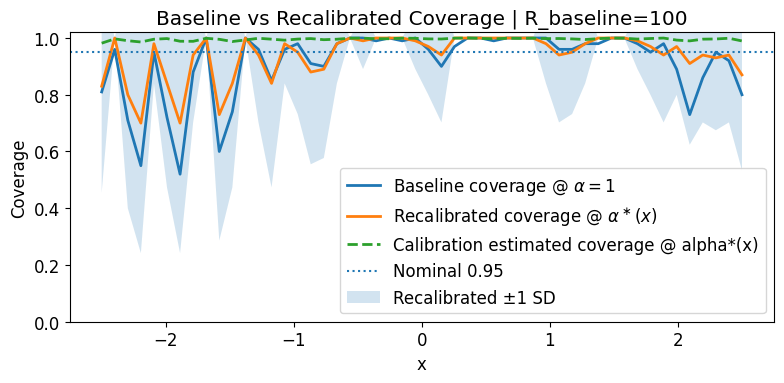

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["font.size"] = 12

# ====== 1. baseline coverage assessment (latent f, alpha=1) ======
BASELINE_DIR    = r"C:\Users\yangy\stage1_complete"
DOUBLECHECK_DIR = r"C:\Users\yangy\reproduction\new_results\doublecheck"

ind_path    = os.path.join(BASELINE_DIR, "indicator_matrix_twostage_symnorm.npy")
health_path = os.path.join(BASELINE_DIR, "health_summary.csv")

print("indicator 矩阵路径:", ind_path)
print("health_summary 路径:", health_path)

indicators = np.load(ind_path)          # 形状 [A, R, J]
health     = pd.read_csv(health_path)   # 有一列 'alpha'
alphas     = health["alpha"].values

A, R_base, J_base = indicators.shape
print(f"indicator_matrix shape: A={A}, R={R_base}, J={J_base}")
print("alphas =", alphas)

# 找到 alpha = 1.0 对应的 index
idx_alpha1 = np.where(np.isclose(alphas, 1.0))[0]
assert len(idx_alpha1) == 1, "health_summary 里没有唯一的 alpha=1.0"
idx_alpha1 = idx_alpha1[0]

baseline_curve = indicators[idx_alpha1].mean(axis=0)  # [J]
baseline_sd    = indicators[idx_alpha1].std(axis=0)   # [J]

# ====== 2. double-check α*(x) 的 coverage 汇总 ======
summary_path = os.path.join(DOUBLECHECK_DIR, "alpha_star_doublecheck_summary_local.csv")
print("double-check summary 路径:", summary_path)

df_dc = pd.read_csv(summary_path)

x_dc       = df_dc["x"].values
dc_mean    = df_dc["emp_cov_mean"].values       # double-check empirical coverage under α*(x)
dc_sd      = df_dc["emp_cov_sd"].values
calib_mean = df_dc["calib_cov_mean"].values     # calibration 阶段估计的 coverage

J_dc = len(x_dc)
print(f"double-check grid 长度 J_dc = {J_dc}")

# 检查 x 网格 & J 是否一致
assert J_base == J_dc, f"baseline J={J_base}, double-check J={J_dc} 不一致"
x_axis = x_dc  # 直接用 double-check 的 x

# ====== 3. 画 baseline vs recalibrated coverage ======
plt.figure()

# baseline：coverage assessment α=1（对真 f0）
plt.plot(x_axis, baseline_curve, label=r"Baseline coverage @ $\alpha=1$", linewidth=2)

# recalibration：double-check empirical coverage under α*(x)
plt.plot(x_axis, dc_mean, label=r"Recalibrated coverage @ $\alpha^\ast(x)$", linewidth=2)

# （可选）把 calibration 阶段估计的 coverage 也画上去
plt.plot(x_axis, calib_mean, "--",
         label="Calibration estimated coverage @ alpha*(x)", linewidth=2)

# nominal 0.95
plt.axhline(0.95, linestyle=":", label="Nominal 0.95")

# 对 recalibration 画 ±1 SD 阴影
plt.fill_between(
    x_axis,
    dc_mean - dc_sd,
    dc_mean + dc_sd,
    alpha=0.2,
    label="Recalibrated ±1 SD"
)

plt.xlabel("x")
plt.ylabel("Coverage")
plt.ylim(0.0, 1.02)
plt.title(f"Baseline vs Recalibrated Coverage | R_baseline={R_base}")
plt.legend()
# tight_layout 也可以留着，这次不会再炸
plt.tight_layout()
plt.show()
